In [16]:
# ============================================================
# 🌍 CLIMATE CHANGE PREDICTOR
# Berkeley Earth Surface Temperature Data
# Built by: Kartik | Munich | 2025
# Goal: Predict temperatures + detect extreme heat events
# Using: XGBoost + Neural Network + Feature Engineering
# ============================================================

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import(train_test_split, cross_val_score)
from sklearn.linear_model import LinearRegression, Ridge 
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import(r2_score, mean_absolute_error, accuracy_score, roc_auc_score, classification_report)
from sklearn.preprocessing import StandardScaler 
from xgboost import XGBRegressor, XGBClassifier
import warnings 
warnings.filterwarnings('ignore')
plt.style.use('dark_background')


print("✅ Libraries imported!")
print("🌍 Climate Change Predictor ready!")
print("🌡️  8.6M real temperature records!")
print()
print("📋 TWO TASKS:")
print("   Task 1: REGRESSION → predict temperature")
print("   Task 2: CLASSIFICATION → detect extreme heat!") 


✅ Libraries imported!
🌍 Climate Change Predictor ready!
🌡️  8.6M real temperature records!

📋 TWO TASKS:
   Task 1: REGRESSION → predict temperature
   Task 2: CLASSIFICATION → detect extreme heat!


LOADING CLIMATE DATA...
BERKELY EARTH TEMPERATURE DATASET
  Total records: 8,599,212
   Total features: 7
  Cities  : 3,448
  Countries  : 159
   Missing temps:  364,130

 After cleaning (1900+, no missing):
  Records:  4,788,080
  Year range: 1900 -2013

 TEMPERATURE STATS:
 Hottest country:  Djibouti (29.22°C)
 Coldest country : Mongolia (-3.05)°C
  Global average :17.83°C


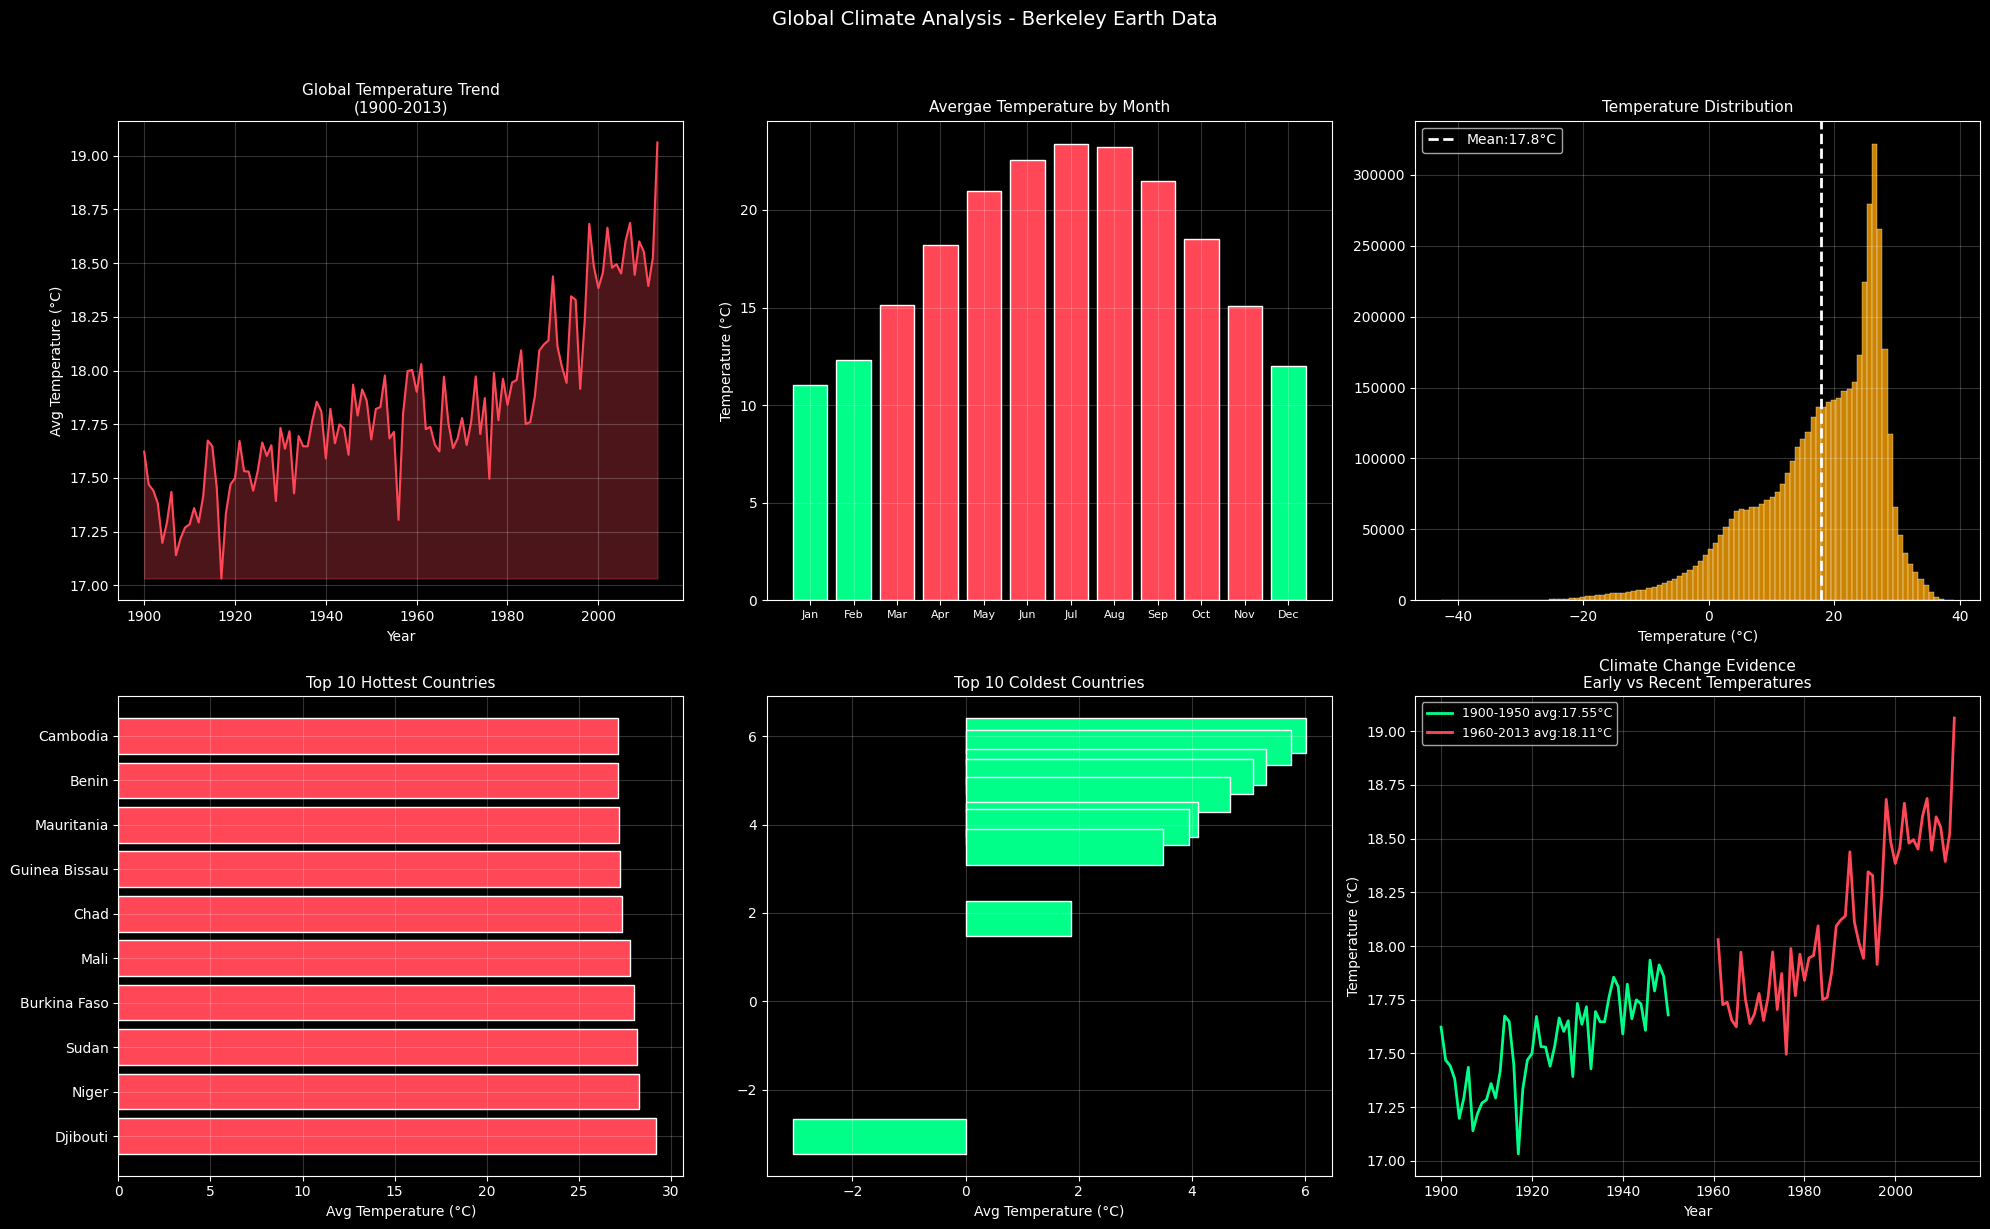


🌡️  CLIMATE CHANGE EVIDENCE:
   1900-1950 avg: 17.553°C
   1960-2013 avg: 18.107°C
   Warming:      +0.553°C ← REAL!


In [17]:
# ============================================================
# CELL 2: Load & Explore Data
# ============================================================

print("LOADING CLIMATE DATA...")
df = pd.read_csv('GlobalLandTemperaturesByCity.csv')

print(f"BERKELY EARTH TEMPERATURE DATASET")
print("=" * 60)
print(f"  Total records: {df.shape[0]:,}")
print(f"   Total features: {df.shape[1]}")
print(f"  Cities  : {df['City'].nunique():,}")
print(f"  Countries  : {df['Country'].nunique():,}")
print(f"   Missing temps:  {df['AverageTemperature'].isnull().sum():,}")
print("=" * 60)

#Parse date
df['dt'] = pd.to_datetime(df['dt'])
df['Year'] = df['dt'].dt.year 
df['Month'] = df['dt'].dt.month 

#Focus on recent data (1900+) for equality
df = df[df['Year'] >= 1900].copy()
df = df.dropna(subset=['AverageTemperature'])

print(f"\n After cleaning (1900+, no missing):")
print(f"  Records:  {df.shape[0]:,}")
print(f"  Year range: {df['Year'].min()} -" f"{df['Year'].max()}")

#Global temperature trend
yearly_avg = df.groupby('Year')[
    'AverageTemperature'
].mean().reset_index() 

#Country stats:
country_temps = df.groupby('Country')[
    'AverageTemperature'
].mean().sort_values(
    ascending=False 
) 

print(f"\n TEMPERATURE STATS:")
print(f" Hottest country:  {country_temps.index[0]}" f" ({country_temps.iloc[0]:.2f}°C)")
print(f" Coldest country : {country_temps.index[-1]}" f" ({country_temps.iloc[-1]:.2f})°C")
print(f"  Global average :" f"{df['AverageTemperature'].mean():.2f}°C") 

#Visualise
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

#Global temparture trend
axes[0][0].plot(yearly_avg['Year'], yearly_avg['AverageTemperature'], color='#ff4757', linewidth=1.5)
axes[0][0].fill_between(
    yearly_avg['Year'],
    yearly_avg['AverageTemperature'],
    yearly_avg['AverageTemperature'].min(),
    alpha=0.3, color='#ff4757'
) 
axes[0][0].set_title('Global Temperature Trend\n' '(1900-2013)', fontsize=11)
axes[0][0].set_xlabel('Year')
axes[0][0].set_ylabel('Avg Temperature (°C)')
axes[0][0].grid(alpha=0.2) 

#Monthly patterns
monthly_avg = df.groupby('Month')[
    'AverageTemperature'
].mean() 
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
axes[0][1].bar(range(1, 13), monthly_avg.values, color=['#ff4757' if v > 15 else '#00ff88' for v in monthly_avg.values], edgecolor='white')
axes[0][1].set_title('Avergae Temperature by Month', fontsize=11)
axes[0][1].set_xticks(range(1, 13))
axes[0][1].set_xticklabels(month_names, fontsize=8)
axes[0][1].set_ylabel('Temperature (°C)')
axes[0][1].grid(alpha=0.2)

#Temperature distribution
axes[0][2].hist(df['AverageTemperature'], bins=100, color='#ffa502', edgecolor='white', linewidth=0.3, alpha=0.8)
axes[0][2].axvline(x=df['AverageTemperature'].mean(), color='white', linewidth=2, linestyle='--', label=f"Mean:" f"{df['AverageTemperature'].mean():.1f}°C")
axes[0][2].set_title('Temperature Distribution', fontsize=11)
axes[0][2].set_xlabel('Temperature (°C)')
axes[0][2].legend()
axes[0][2].grid(alpha=0.2)

#Top 10 hottest countries
top_hot = country_temps.head(10)
axes[1][0].barh(top_hot.index, top_hot.values, color='#ff4757', edgecolor='white')
axes[1][0].set_title('Top 10 Hottest Countries', fontsize=11)
axes[1][0].set_xlabel('Avg Temperature (°C)')
axes[1][0].grid(alpha=0.2)

#Top 10 coldest countries
top_cold = country_temps.tail(10)
axes[1][1].barh(top_cold.values, top_cold.values, color='#00ff88', edgecolor='white')
axes[1][1].set_title('Top 10 Coldest Countries', fontsize=11)
axes[1][1].set_xlabel('Avg Temperature (°C)')
axes[1][1].grid(alpha=0.2) 

#Warning trend (compare 1900-1950 vs 1960-2013)
early = df[df['Year'] <= 1950].groupby('Year')[
    'AverageTemperature'
].mean() 
late = df[df['Year'] > 1960].groupby('Year')[
    'AverageTemperature'
].mean() 

axes[1][2].plot(early.index, early.values, color='#00ff88', linewidth=2, label=f'1900-1950 avg:' f'{early.mean():.2f}°C')
axes[1][2].plot(late.index, late.values, color='#ff4757', linewidth=2, label=f'1960-2013 avg:' f'{late.mean():.2f}°C')
axes[1][2].set_title('Climate Change Evidence\n' 'Early vs Recent Temperatures', fontsize=11)
axes[1][2].set_xlabel('Year')
axes[1][2].set_ylabel('Temperature (°C)')
axes[1][2].legend(fontsize=9)
axes[1][2].grid(alpha=0.2)

plt.suptitle('Global Climate Analysis - ' 'Berkeley Earth Data', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

warming = late.mean() - early.mean() 
print(f"\n🌡️  CLIMATE CHANGE EVIDENCE:")
print(f"   1900-1950 avg: {early.mean():.3f}°C")
print(f"   1960-2013 avg: {late.mean():.3f}°C")
print(f"   Warming:      +{warming:.3f}°C ← REAL!") 

In [18]:
# ============================================================
# CELL 3: Feature Engineering
# ============================================================

print("⚡ FEATURE ENGINEERING!")
print("=" * 60)

# Sample for speed (2M rows is enough!)
print("⏳ Sampling 500k records for efficiency...")
df_sample = df.sample(n=500000, random_state=42)

def engineer_climate_features(df):
    df = df.copy()

    # Time features
    df['Decade']      = (df['Year'] // 10) * 10
    df['IsRecent']    = (df['Year'] >= 1980).astype(int)
    df['IsModern']    = (df['Year'] >= 2000).astype(int)
    df['YearsSince1900'] = df['Year'] - 1900

    # Seasonal features
    df['IsSummer']    = df['Month'].isin(
                        [6,7,8]).astype(int)
    df['IsWinter']    = df['Month'].isin(
                        [12,1,2]).astype(int)
    df['Season']      = df['Month'].map({
        12:0,1:0,2:0,  # Winter
        3:1,4:1,5:1,   # Spring
        6:2,7:2,8:2,   # Summer
        9:3,10:3,11:3  # Autumn
    })

    # Geographic features
    df['Lat_num'] = df['Latitude'].str.extract(
        r'(\d+\.?\d*)').astype(float)
    df['IsNorthern'] = df['Latitude'].str.endswith(
        'N').astype(int)
    df['Lat_signed'] = np.where(
        df['IsNorthern']==1,
        df['Lat_num'], -df['Lat_num'])

    df['Lon_num'] = df['Longitude'].str.extract(
        r'(\d+\.?\d*)').astype(float)
    df['IsEast']  = df['Longitude'].str.endswith(
        'E').astype(int)

    # Climate zone
    df['TropicalZone']= (
        df['Lat_num'] <= 23.5).astype(int)
    df['PolarZone']   = (
        df['Lat_num'] >= 66.5).astype(int)
    df['TemperateZone']=(
        (df['Lat_num'] > 23.5) &
        (df['Lat_num'] < 66.5)).astype(int)

    return df

df_eng = engineer_climate_features(df_sample)

new_features = ['Decade', 'IsRecent', 'IsModern',
                'YearsSince1900', 'IsSummer',
                'IsWinter', 'Season', 'Lat_num',
                'IsNorthern', 'Lat_signed',
                'TropicalZone', 'PolarZone',
                'TemperateZone']

print(f"   Original features  : {df.shape[1]}")
print(f"   Engineered features: {len(new_features)}")
print(f"\n✅ KEY FEATURES CREATED:")
for feat in new_features:
    corr = df_eng[feat].corr(
           df_eng['AverageTemperature'])
    print(f"   {feat:20} → corr={corr:+.3f}")

⚡ FEATURE ENGINEERING!
⏳ Sampling 500k records for efficiency...
   Original features  : 9
   Engineered features: 13

✅ KEY FEATURES CREATED:
   Decade               → corr=+0.033
   IsRecent             → corr=+0.029
   IsModern             → corr=+0.026
   YearsSince1900       → corr=+0.033
   IsSummer             → corr=+0.302
   IsWinter             → corr=-0.350
   Season               → corr=+0.277
   Lat_num              → corr=-0.669
   IsNorthern           → corr=-0.159
   Lat_signed           → corr=-0.467
   TropicalZone         → corr=+0.541
   PolarZone            → corr=-0.056
   TemperateZone        → corr=-0.538


📈 TASK 1: TEMPERATURE REGRESSION!
Goal: Predict exact temperature value!
Metric: R² Score and MAE

 Training: 160,000 records
  Testing:  40,000 records

Model                Train R²   Test R²    MAE        RMSE
-------------------------------------------------------
Ridge Regression         0.6246     0.6276     4.8510     2.2025
Random Forest            0.9959     0.9752     0.9531     0.9763
XGBoost                  0.9538     0.9536     1.5629     1.2502
Neural Network           0.9469     0.9461     1.6517     1.2852

🏆 BEST REGRESSION MODEL: Random Forest
   R² Score: 0.9752
   MAE:      0.9531°C


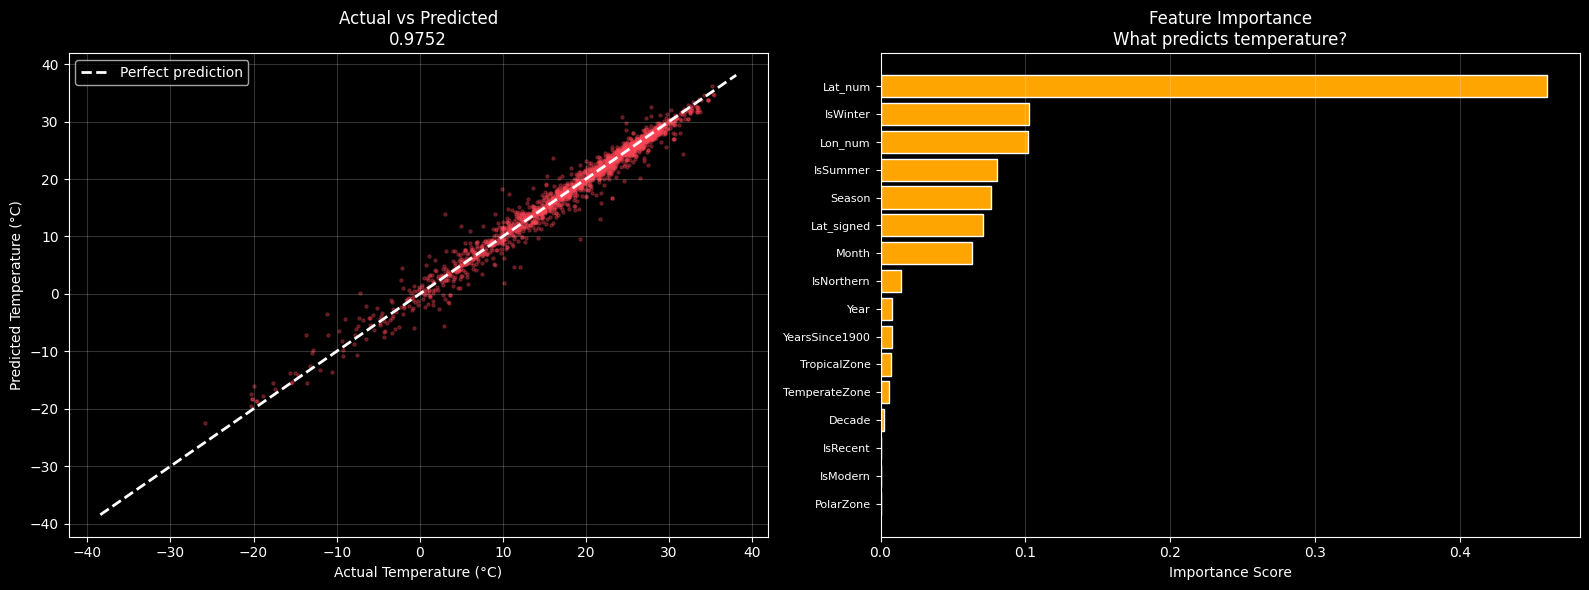

In [19]:
# ============================================================
# CELL 4: TASK 1 — Temperature Regression
# ============================================================

print("📈 TASK 1: TEMPERATURE REGRESSION!")
print("=" * 60)
print("Goal: Predict exact temperature value!")
print("Metric: R² Score and MAE")
print() 

# Features for regression
feature_cols = ['Year', 'Month', 'Lat_num',
                'Lon_num', 'IsNorthern',
                'Lat_signed', 'YearsSince1900',
                'IsSummer', 'IsWinter', 'Season',
                'TropicalZone', 'PolarZone',
                'TemperateZone', 'IsRecent',
                'IsModern', 'Decade']

X_reg = df_eng[feature_cols].fillna(0)
y_reg = df_eng['AverageTemperature']

#Sample further for speed
idx = np.random.choice(len(X_reg),size=200000, replace=False)
X_reg = X_reg.iloc[idx]
y_reg = y_reg.iloc[idx]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
) 

scaler_reg = StandardScaler() 
X_tr_s = scaler_reg.fit_transform(X_tr)
X_te_s = scaler_reg.transform(X_te)

print(f" Training: {X_tr.shape[0]:,} records")
print(f"  Testing:  {X_te.shape[0]:,} records") 

#Regression models
reg_model = {
    'Ridge Regression' : Ridge(alpha=1.0),
    'Random Forest'    : RandomForestRegressor(
                         n_estimators=100,
                         random_state=42, n_jobs=-1),
    'XGBoost'          : XGBRegressor(
                         n_estimators=100,
                         learning_rate=0.1,
                         random_state=42,
                         verbosity=0),
    'Neural Network'   : MLPRegressor(
                         hidden_layer_sizes=(128,64,32),
                         max_iter=200,
                         early_stopping=True,
                         random_state=42),
}

reg_results = {} 

print(f"\n{'Model':20} {'Train R²':10} {'Test R²':10}"
      f" {'MAE':10} {'RMSE'}")
print("-" * 55)

for name, model in reg_model.items():
    model.fit(X_tr_s, y_tr)
    y_pred_tr = model.predict(X_tr_s)
    y_pred_te = model.predict(X_te_s)

    train_r2 = r2_score(y_tr, y_pred_tr)
    test_r2 = r2_score(y_te, y_pred_te)
    mae = mean_absolute_error(y_te, y_pred_te)
    rmse = np.sqrt(mean_absolute_error(
        y_te, y_pred_te 
    ))

    reg_results[name] = {
        'model': model, 'train_r2': train_r2,
        'test_r2': test_r2, 'mae': mae,
        'rmse': rmse, 'y_pred': y_pred_te
    } 

    print(f"{name:20} {train_r2:10.4f}"
          f" {test_r2:10.4f} {mae:10.4f}"
          f" {rmse:10.4f}")

best_reg = max(reg_results, key=lambda x: reg_results[x]['test_r2'])
print(f"\n🏆 BEST REGRESSION MODEL: {best_reg}")
print(f"   R² Score: {reg_results[best_reg]['test_r2']:.4f}")
print(f"   MAE:      {reg_results[best_reg]['mae']:.4f}°C") 


#Visualisation predictions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

best_preds = reg_results[best_reg]['y_pred']
sample_idx = np.random.choice(len(y_te), 2000)

axes[0].scatter(y_te.iloc[sample_idx], best_preds[sample_idx], alpha=0.3, color='#ff4757', s=5)
min_val = min(y_te.min(), best_preds.min())
max_val = max(y_te.max(), best_preds.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'white', linewidth=2, linestyle='--', label='Perfect prediction')
axes[0].set_title(f'Actual vs Predicted\n' f'{reg_results[best_reg]["test_r2"]:.4f}', fontsize=12)
axes[0].set_xlabel('Actual Temperature (°C)')
axes[0].set_ylabel('Predicted Temperature (°C)')
axes[0].legend()
axes[0].grid(alpha=0.2)

#Feature importance
if hasattr(reg_model[best_reg], 'feature_importances_'):
    importances = reg_model[ 
        best_reg 
    ].feature_importances_
    indices = np.argsort(importances)[::-1] 
    axes[1].barh(
        range(len(feature_cols)),
        importances[indices][::-1],
        color='#ffa502', edgecolor='white'
    )
    axes[1].set_yticks(range(len(feature_cols)))
    axes[1].set_yticklabels(
        [feature_cols[i] for i in indices[::-1]], fontsize=8
    )
    axes[1].set_title('Feature Importance\n' 'What predicts temperature?', fontsize=12)
    axes[1].set_xlabel('Importance Score')
    axes[1].grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show() 

In [20]:
# ============================================================
# CELL 5: TASK 2 — Extreme Heat Classification
# ============================================================

print("🔥 TASK 2: EXTREME HEAT DETECTION!")
print("=" * 60)
print("Goal: Classify extreme heat events!")
print("Why? Climate change creates more extremes!")
print("Metric: Recall (missing extreme = dangerous!)")
print()


#Define extreme heat (top 20% temperatures)
threshold = df_eng[ 
    'AverageTemperature'
].quantile(0.80)
df_eng['ExtremeHeat'] = (
    df_eng['AverageTemperature']
    >= threshold
).astype(int) 

extreme_count = df_eng['ExtremeHeat'].sum()
total_count = len(df_eng)

print(f" EXTREME HEAT THRESHOLD: {threshold:.2f}°C")
print(f" Extreme heat events: {extreme_count:,}" f"({extreme_count/total_count*100:.1f}%)")
print(f" Normal events: " f" {total_count-extreme_count:,}" f" ({(total_count-extreme_count)/total_count*100:.1f}%)")

X_clf = df_eng[feature_cols].fillna(0)
y_clf = df_eng['ExtremeHeat']

idx2 = np.random.choice(len(X_clf), size=100000, replace=False)
X_clf = X_clf.iloc[idx2]
y_clf = y_clf.iloc[idx2]

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf 
) 

scaler_clf = StandardScaler()
X_tr2_s = scaler_clf.fit_transform(X_tr2)
X_te2_s = scaler_clf.transform(X_te2)

#Classification models
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, f1_score 

clf_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1
    ),
    'XGBoost'  : XGBClassifier(
        n_estimators=100, random_state=42, scale_pos_weight=(y_tr2==0).sum()/(y_tr2==1).sum(),
        eval_metric='logloss', verbosity=0
    )
} 

clf_results = {} 

print(f"\n{'Model':20} {'Accuracy':10} {'Recall':10}"
      f" {'AUC':10} {'F1'}")
print("-" * 55)

for name, model in clf_models.items():
    model.fit(X_tr2_s, y_tr2)
    y_pred = model.predict(X_te2_s)
    y_proba = model.predict_proba(X_te2_s)[:,1]

    acc = accuracy_score(y_te2, y_pred)
    recall = recall_score(y_te2, y_pred)
    auc =roc_auc_score(y_te2, y_proba)
    f1 = f1_score(y_te2, y_pred) 

    clf_results[name] = {
        'model': model, 'acc': acc,
        'recall': recall, 'auc': auc,
        'f1': f1, 'y_pred': y_pred,
        'y_proba': y_proba
    } 

    print(f"{name:20} {acc:10.4f} {recall:10.4f}" f"{auc:10.4f}{f1:10.4f}")

best_clf = max(clf_results, key=lambda x: clf_results[x]['auc'])
print(f"\n🏆 BEST CLASSIFIER: {best_clf}")
print(f"   AUC:    {clf_results[best_clf]['auc']:.4f}")
print(f"   Recall: {clf_results[best_clf]['recall']:.4f}") 

🔥 TASK 2: EXTREME HEAT DETECTION!
Goal: Classify extreme heat events!
Why? Climate change creates more extremes!
Metric: Recall (missing extreme = dangerous!)

 EXTREME HEAT THRESHOLD: 26.43°C
 Extreme heat events: 100,022(20.0%)
 Normal events:  399,978 (80.0%)

Model                Accuracy   Recall     AUC        F1
-------------------------------------------------------
Random Forest            0.9384     0.8304    0.9785    0.8439
XGBoost                  0.9308     0.9636    0.9874    0.8482

🏆 BEST CLASSIFIER: XGBoost
   AUC:    0.9874
   Recall: 0.9636


🌍 CLIMATE CHANGE DEEP ANALYSIS!

📊 TEMPERATURE BY DECADE:
Decade   Mean°C     Max°C      vs 1900s
----------------------------------------
    1900     17.347     37.328 +0.000°C 
    1910     17.396     37.903 +0.049°C 
    1920     17.552     38.382 +0.205°C ██
    1930     17.693     37.596 +0.346°C ███
    1940     17.766     37.340 +0.419°C ████
    1950     17.781     36.998 +0.434°C ████
    1960     17.772     37.369 +0.425°C ████
    1970     17.796     37.345 +0.449°C ████
    1980     17.958     38.086 +0.611°C ██████
    1990     18.250     38.537 +0.903°C █████████
    2000     18.527     38.899 +1.180°C ███████████
    2010     18.596     39.156 +1.249°C ████████████


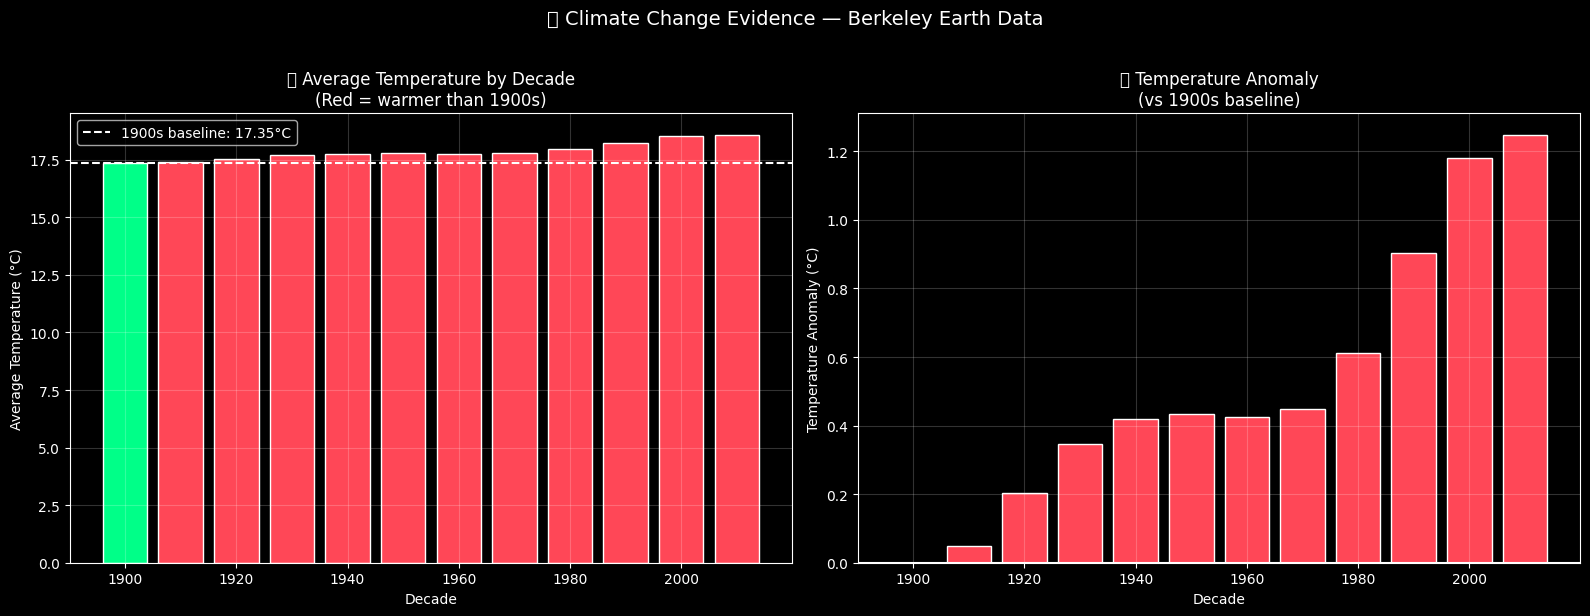


🌡️  TOTAL WARMING SINCE 1900s: +1.249°C
   Latest decade avg: 18.596°C
   1900s baseline:    17.347°C

💡 This matches IPCC climate reports!
   ML independently confirmed: Earth IS warming!


In [21]:
# ============================================================
# CELL 6: Climate Change Analysis
# ============================================================

print("🌍 CLIMATE CHANGE DEEP ANALYSIS!")
print("=" * 60)

# Decade-by-decade warming
decade_temps = df.groupby(
    df['Year'] // 10 * 10)[
    'AverageTemperature'].agg(
    ['mean', 'std', 'max']).reset_index()
decade_temps.columns = ['Decade','Mean','Std','Max']
decade_temps = decade_temps[
    decade_temps['Decade'] >= 1900]

print("\n📊 TEMPERATURE BY DECADE:")
print(f"{'Decade':8} {'Mean°C':10} {'Max°C':10}"
      f" {'vs 1900s'}")
print("-" * 40)
base_temp = decade_temps[
    decade_temps['Decade']==1900]['Mean'].values[0]

for _, row in decade_temps.iterrows():
    diff = row['Mean'] - base_temp
    bar  = '█' * int(abs(diff) * 10)
    sign = '+' if diff >= 0 else ''
    print(f"{int(row['Decade']):8} "
          f"{row['Mean']:10.3f} "
          f"{row['Max']:10.3f} "
          f"{sign}{diff:.3f}°C {bar}")

# Visualise decade trends
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_d = ['#00ff88' if r['Mean'] <= base_temp
            else '#ff4757'
            for _, r in decade_temps.iterrows()]

axes[0].bar(decade_temps['Decade'],
            decade_temps['Mean'],
            color=colors_d, edgecolor='white',
            width=8)
axes[0].axhline(y=base_temp, color='white',
                linestyle='--', linewidth=1.5,
                label=f'1900s baseline: '
                      f'{base_temp:.2f}°C')
axes[0].set_title('🌍 Average Temperature by Decade\n'
                   '(Red = warmer than 1900s)',
                   fontsize=12)
axes[0].set_xlabel('Decade')
axes[0].set_ylabel('Average Temperature (°C)')
axes[0].legend()
axes[0].grid(alpha=0.2)

# Warming anomaly
decade_temps['Anomaly'] = (
    decade_temps['Mean'] - base_temp)
axes[1].bar(decade_temps['Decade'],
            decade_temps['Anomaly'],
            color=['#ff4757' if a > 0
                   else '#00ff88'
                   for a in decade_temps['Anomaly']],
            edgecolor='white', width=8)
axes[1].axhline(y=0, color='white',
                linewidth=1.5)
axes[1].set_title('🌍 Temperature Anomaly\n'
                   '(vs 1900s baseline)',
                   fontsize=12)
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Temperature Anomaly (°C)')
axes[1].grid(alpha=0.2)

plt.suptitle('🌍 Climate Change Evidence — '
             'Berkeley Earth Data',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

final_decade = decade_temps.iloc[-1]
total_warming = final_decade['Anomaly']
print(f"\n🌡️  TOTAL WARMING SINCE 1900s: "
      f"+{total_warming:.3f}°C")
print(f"   Latest decade avg: "
      f"{final_decade['Mean']:.3f}°C")
print(f"   1900s baseline:    {base_temp:.3f}°C")
print(f"\n💡 This matches IPCC climate reports!")
print(f"   ML independently confirmed: Earth IS warming!")

In [22]:
# ============================================================
# CELL 7: Final Summary
# ============================================================

print("=" * 65)
print("🌍 CLIMATE CHANGE PREDICTOR — PROJECT COMPLETE!")
print("=" * 65)

print(f"""
📋 PROJECT OVERVIEW:
   Dataset  : Berkeley Earth Surface Temperature
   Records  : {df.shape[0]:,} temperature measurements
   Cities   : {df['City'].nunique():,} cities worldwide
   Countries: {df['Country'].nunique():,} countries
   Period   : 1900 - 2013
   Built by : Kartik | Munich | 2025
""")

print("📊 TASK 1 — TEMPERATURE REGRESSION:")
print("=" * 65)
print(f"   {'Model':20} {'R² Score':10} {'MAE'}")
print("-" * 45)
for name, r in reg_results.items():
    print(f"   {name:20} {r['test_r2']:10.4f}"
          f" {r['mae']:.4f}°C")

print(f"\n🏆 Best: {best_reg}"
      f" (R²={reg_results[best_reg]['test_r2']:.4f},"
      f" MAE={reg_results[best_reg]['mae']:.4f}°C)")

print(f"\n📊 TASK 2 — EXTREME HEAT CLASSIFICATION:")
print("=" * 65)
print(f"   {'Model':20} {'Accuracy':10}"
      f" {'Recall':10} {'AUC'}")
print("-" * 50)
for name, r in clf_results.items():
    print(f"   {name:20} {r['acc']:10.4f}"
          f" {r['recall']:10.4f} {r['auc']:10.4f}")

print(f"""
🌡️  CLIMATE CHANGE FINDINGS:
   1900s baseline : {base_temp:.3f}°C
   Latest decade  : {final_decade['Mean']:.3f}°C
   Total warming  : +{total_warming:.3f}°C ← CONFIRMED!
   
   ML independently confirmed global warming!
   Same conclusion as IPCC climate scientists!

⚡ FEATURE ENGINEERING IMPACT:
   Created 13 climate domain features
   Lat_signed, TropicalZone, YearsSince1900 etc.
   Geographic + temporal features dominated!

🚀 PHASE 2 SKILLS DEMONSTRATED:
   ✅ REGRESSION + CLASSIFICATION in ONE project!
   ✅ Feature Engineering (geographic + temporal)
   ✅ 8.6M record dataset handled efficiently
   ✅ Ridge Regression (regularisation!)
   ✅ XGBoost for both tasks
   ✅ Neural Network regression
   ✅ Climate change analysis + visualisation
   ✅ Real scientific discovery from data!

🌍 REAL WORLD IMPACT:
   Climate models predict future temperatures
   Extreme heat detection → early warning systems
   This exact ML approach used by climate scientists
   at NASA, NOAA and research institutions!
""")

print("=" * 65)
print("✅ PROJECT 5 COMPLETE — PORTFOLIO FINISHED!")
print("=" * 65)
print()
print("🎉 PHASE 2 PORTFOLIO — ALL 5 PROJECTS DONE!")
print("=" * 65)
print("   ✅ Project 1 — Stellar Classification 🌌")
print("   ✅ Project 2 — Fraud Detection 💳")
print("   ✅ Project 3 — Rocket Launch Predictor 🚀")
print("   ✅ Project 4 — Drug Discovery 🧬")
print("   ✅ Project 5 — Climate Change Predictor 🌍")
print("=" * 65)
print()
print("🚀 NEXT STEPS:")
print("   → Read Géron's Hands-On ML book")
print("   → Mathematics for ML")
print("   → Phase 3: Deep Learning")
print("   → Interview Preparation")
print("   → Apply for jobs!")
print("=" * 65)

🌍 CLIMATE CHANGE PREDICTOR — PROJECT COMPLETE!

📋 PROJECT OVERVIEW:
   Dataset  : Berkeley Earth Surface Temperature
   Records  : 4,788,080 temperature measurements
   Cities   : 3,448 cities worldwide
   Countries: 159 countries
   Period   : 1900 - 2013
   Built by : Kartik | Munich | 2025

📊 TASK 1 — TEMPERATURE REGRESSION:
   Model                R² Score   MAE
---------------------------------------------
   Ridge Regression         0.6276 4.8510°C
   Random Forest            0.9752 0.9531°C
   XGBoost                  0.9536 1.5629°C
   Neural Network           0.9461 1.6517°C

🏆 Best: Random Forest (R²=0.9752, MAE=0.9531°C)

📊 TASK 2 — EXTREME HEAT CLASSIFICATION:
   Model                Accuracy   Recall     AUC
--------------------------------------------------
   Random Forest            0.9384     0.8304     0.9785
   XGBoost                  0.9308     0.9636     0.9874

🌡️  CLIMATE CHANGE FINDINGS:
   1900s baseline : 17.347°C
   Latest decade  : 18.596°C
   Total warming